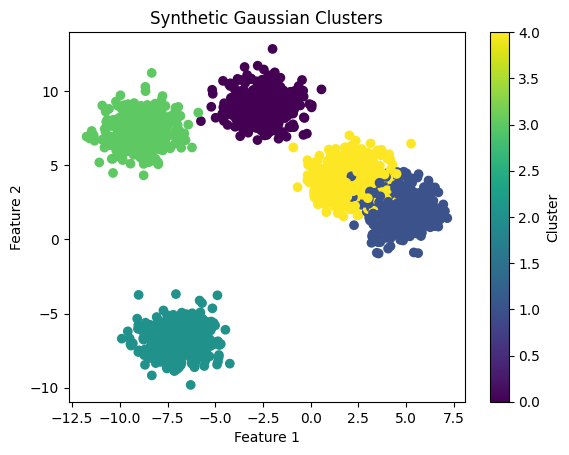

X shape: (2000, 2)
y shape: (2000,)


In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate synthetic 2D Gaussian clusters
n_samples = 2000
n_clusters = 5
X, y = make_blobs(
    n_samples=n_samples, centers=n_clusters, cluster_std=1.0, random_state=42
)

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")
plt.title("Synthetic Gaussian Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster")
plt.show()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Create train and test datasets
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Create the validation dataset from the test dataset
x_test, x_val, y_test, y_val = train_test_split(
    x_test, y_test, test_size=0.5, random_state=42
)

# Create a TensorDatasets
dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.int64)
)
dataset_val = TensorDataset(
    torch.tensor(x_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.int64)
)

# Create a DataLoader
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)

In [3]:
from ptmelt.models import VariationalAutoencoder
from torchinfo import summary
from torch import optim

# Instantiate the Variational Autoencoder
input_dims = X.shape[1]  # Number of features
latent_dims = 8  # Latent space dimensions
encoder_node_list = [32, 16]  # Number of nodes in each hidden layer of the encoder
decoder_node_list = [16, 32]  # Number of nodes in each hidden layer of the decoder
num_mixtures = 5  # Match the number of clusters
learn_rate = 1e-3

vae_model = VariationalAutoencoder(
    num_features=input_dims,
    num_outputs=input_dims,
    latent_dims=latent_dims,
    encoder_node_list=encoder_node_list,
    decoder_node_list=decoder_node_list,
    num_mixtures=num_mixtures,
    l2_reg=1e-3,
)

# Build the model and print the summary
vae_model.build()
print(summary(vae_model, input_size=(1, input_dims)))

# Define the loss function and optimizer for training
criterion = vae_model.get_loss_fn(loss="mse", reduction="mean", mse_weight=None)
optimizer = vae_model.get_optimizer("Adam", lr=learn_rate)
scheduler = vae_model.get_scheduler(
    "ReduceLROnPlateau",
    optimizer,
    factor=0.5,
    patience=200,
    min_lr=1e-6,
    mode="min",
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=100,
)

print(f"Criterion: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Scheduler: {scheduler}")

/Users/nwimer/miniconda3/envs/pt-melt/lib/python3.12/site-packages/torch/nn/modules/module.py:1532: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Layer (type:depth-idx)                   Output Shape              Param #
VariationalAutoencoder                   [1, 2]                    --
├─ModuleDict: 1-1                        --                        825
│    └─DenseBlock: 2-1                   [1, 16]                   --
│    │    └─ModuleDict: 3-1              --                        624
│    └─MixtureDensityOutput: 2-2         [1, 85]                   --
│    │    └─Linear: 3-2                  [1, 5]                    85
│    │    └─Softmax: 3-3                 [1, 5]                    --
│    │    └─Linear: 3-4                  [1, 40]                   680
│    │    └─Linear: 3-5                  [1, 40]                   680
│    └─Reparameterization: 2-3           [1, 8]                    --
│    └─DenseBlock: 2-4                   [1, 32]                   --
│    │    └─ModuleDict: 3-6              --                        688
│    └─DefaultOutput: 2-5                [1, 2]                    --
│    │    

In [4]:
# Fit the model using the built-in training loop
vae_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    num_epochs=1000,
    verbose=True,
)

history = vae_model.history

  0%|          | 0/1000 [00:00<?, ?it/s]/Users/nwimer/miniconda3/envs/pt-melt/lib/python3.12/site-packages/torch/nn/modules/module.py:1532: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
  1%|          | 11/1000 [00:00<01:09, 14.18it/s]

Epoch 10, Loss: 4.9219, Val Loss: 4.5692, LR: 1.0000e-03


  2%|▏         | 23/1000 [00:01<01:06, 14.79it/s]

Epoch 20, Loss: 3.7275, Val Loss: 3.5185, LR: 1.0000e-03


  3%|▎         | 31/1000 [00:02<01:05, 14.70it/s]

...

Epoch 980, Loss: 2.6052, Val Loss: 2.3820, LR: 2.5000e-04


 99%|█████████▉| 993/1000 [01:05<00:00, 15.38it/s]

Epoch 990, Loss: 2.6690, Val Loss: 2.2816, LR: 2.5000e-04


100%|██████████| 1000/1000 [01:05<00:00, 15.16it/s]

Epoch 1000, Loss: 2.4896, Val Loss: 2.2521, LR: 2.5000e-04


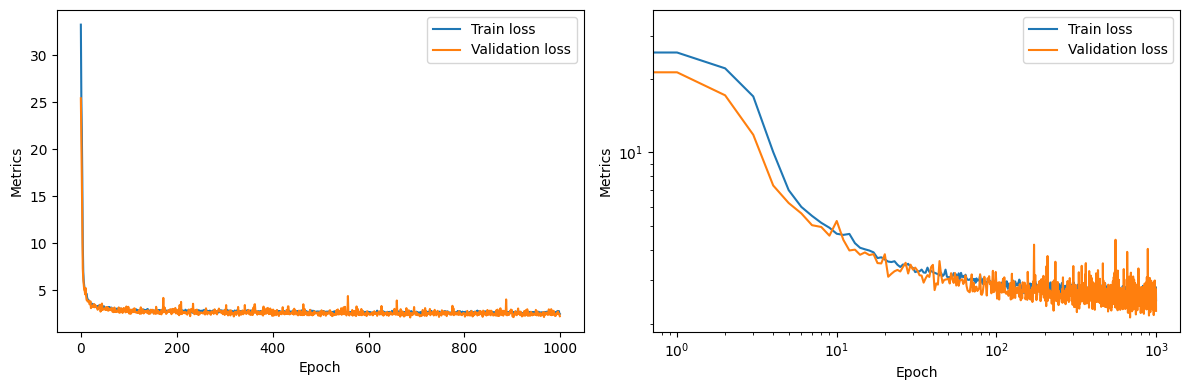

In [5]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, plot_log=True)

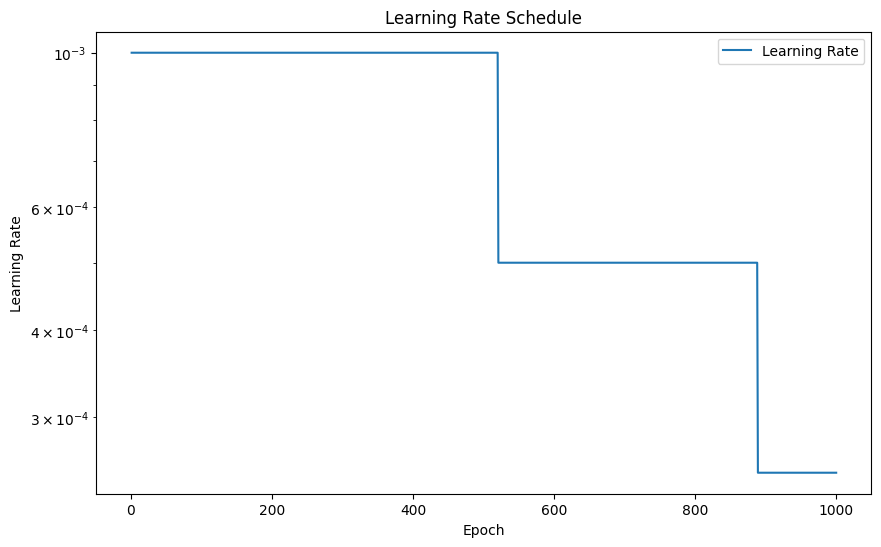

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(history["epoch"], history["lr"], label="Learning Rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend()

In [7]:
print(np.array(history["kl_loss"]).shape)
print(np.array(history["recon_loss"]).shape)
print(len(history["epoch"]))

(1000,)
(1000,)
1000


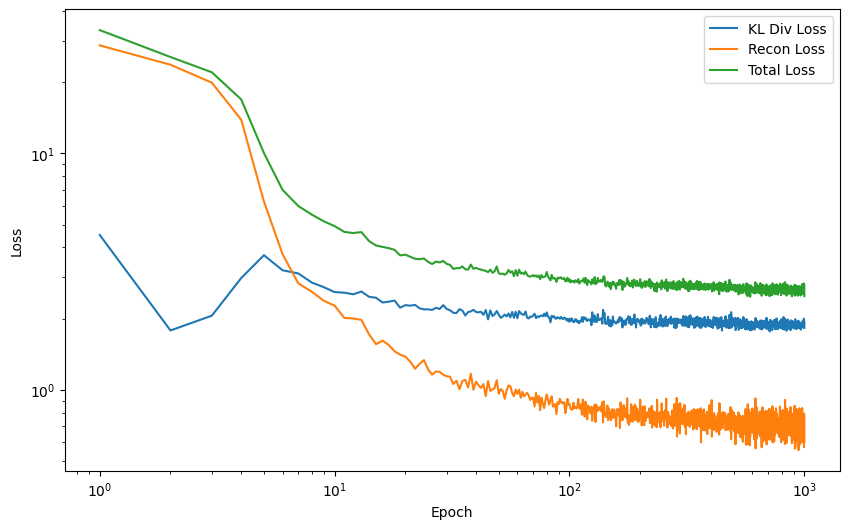

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(history["epoch"], np.array(history["kl_loss"]), label="KL Div Loss")
ax.loglog(history["epoch"], np.array(history["recon_loss"]), label="Recon Loss")
ax.loglog(history["epoch"], np.array(history["loss"]), label="Total Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
# ax.set_title("KL Divergence Loss Schedule")
ax.legend()

/Users/nwimer/miniconda3/envs/pt-melt/lib/python3.12/site-packages/torch/nn/modules/module.py:1532: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


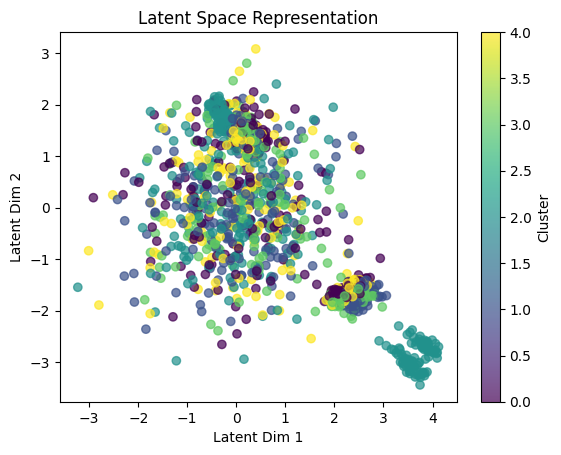

<Figure size 640x480 with 0 Axes>

In [10]:
# Switch to evaluation mode
vae_model.eval()

# Encode the data to the latent space
with torch.no_grad():
    x_encoded = vae_model.layer_dict["encoder_block"](
        torch.tensor(x_train, dtype=torch.float32)
    )
    mdn_output = vae_model.layer_dict["encoder_output"](x_encoded)
    mix_coeffs, means, log_vars = vae_model.split_mdn_output(mdn_output)

# Sample latent space points
# z = model.reparam_layer(mix_coeffs, means, log_vars)
z = vae_model.layer_dict["reparameterization_layer"](mix_coeffs, means, log_vars)

# Visualize the latent space
z = z.numpy()
plt.scatter(z[:, 0], z[:, 1], c=y_train, cmap="viridis", alpha=0.7)
plt.title("Latent Space Representation")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.colorbar(label="Cluster")
plt.show()


plt.tight_layout()
plt.show()

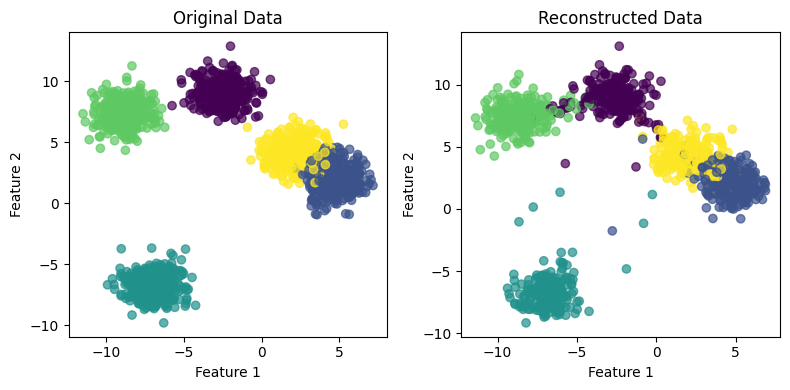

In [11]:
# Decode points from latent space back to input space
with torch.no_grad():
    x_reconstructed = vae_model.layer_dict["decoder_block"](
        torch.tensor(z, dtype=torch.float32)
    )
    x_reconstructed = vae_model.layer_dict["decoder_output"](x_reconstructed)

x_reconstructed = x_reconstructed.numpy()

# Plot original and reconstructed points
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="viridis", alpha=0.7)
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.scatter(
    x_reconstructed[:, 0], x_reconstructed[:, 1], c=y_train, cmap="viridis", alpha=0.7
)
plt.title("Reconstructed Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()